# Data Partition Analysis

Visualises how training data is distributed across clients for any experiment.
Reads `partition_stats.csv` and `config.json` produced by every run.

Each experiment logs:
- `partition_stats.csv` — `client_id, class_id, num_samples` (one row per client×class)
- `config.json` — partition type, alpha, num_clients, dataset, …

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path

## Configuration — point to an experiment

In [4]:
LOGS_ROOT = Path(r'c:\Users\asus\Desktop\TREES\tanguy progress\code\FederatedLearningFramework\logs')

# Set experiment folder name (leave TIMESTAMP as None to auto-pick the latest)
EXPERIMENT = 'test_partition_logging'
TIMESTAMP   = None   # e.g. '2026-03-06_12-00-00', or None for latest

# CIFAR-10 class names (edit for other datasets)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ── Resolve path ────────────────────────────────────────────────────────────
exp_base = LOGS_ROOT / EXPERIMENT
if TIMESTAMP:
    EXP_DIR = exp_base / TIMESTAMP
else:
    runs = sorted([d for d in exp_base.iterdir() if d.is_dir()])
    if not runs:
        raise FileNotFoundError(f'No runs found in {exp_base}')
    EXP_DIR = runs[-1]

print(f'Experiment dir : {EXP_DIR}')

# ── Load data ────────────────────────────────────────────────────────────────
partition_csv = EXP_DIR / 'partition_stats.csv'
config_json   = EXP_DIR / 'config.json'

if not partition_csv.exists():
    raise FileNotFoundError(
        f'{partition_csv} not found.\n'
        'partition_stats.csv is only generated by experiments run after the logging update.\n'
        'Point EXPERIMENT to a newer run, or re-run your experiment.'
    )

df = pd.read_csv(partition_csv)
with open(config_json) as f:
    cfg = json.load(f)

num_clients = cfg.get('num_clients', df['client_id'].nunique())
partition    = cfg.get('partition', '?')
alpha        = cfg.get('alpha', '?')
dataset      = cfg.get('dataset', '?')

print(f'Dataset        : {dataset}')
print(f'Partition      : {partition}  (alpha={alpha})')
print(f'Clients        : {num_clients}')
print(f'Total samples  : {df["num_samples"].sum():,}')
df.head()

Experiment dir : c:\Users\asus\Desktop\TREES\tanguy progress\code\FederatedLearningFramework\logs\test_partition_logging\2026-03-06_14-59-04
Dataset        : cifar10
Partition      : dirichlet  (alpha=0.5)
Clients        : 4
Total samples  : 50,000


,client_id,class_id,num_samples
0,0,0,119
1,0,1,24
2,0,2,1461
3,0,3,898
4,0,4,2483


## 1 · Samples per client (total)

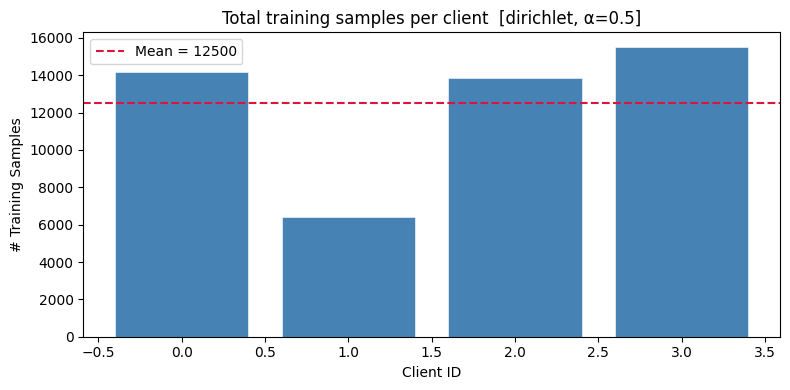

Min: 6400  |  Max: 15525  |  Std: 4128.7


In [5]:
client_totals = df.groupby('client_id')['num_samples'].sum().sort_index()
mean_n = client_totals.mean()

fig, ax = plt.subplots(figsize=(max(8, num_clients // 3), 4))
bars = ax.bar(client_totals.index, client_totals.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axhline(mean_n, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {mean_n:.0f}')
ax.set_xlabel('Client ID')
ax.set_ylabel('# Training Samples')
ax.set_title(f'Total training samples per client  [{partition}, α={alpha}]')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min: {client_totals.min()}  |  Max: {client_totals.max()}  |  Std: {client_totals.std():.1f}')

## 2 · Class distribution heatmap (clients × classes)

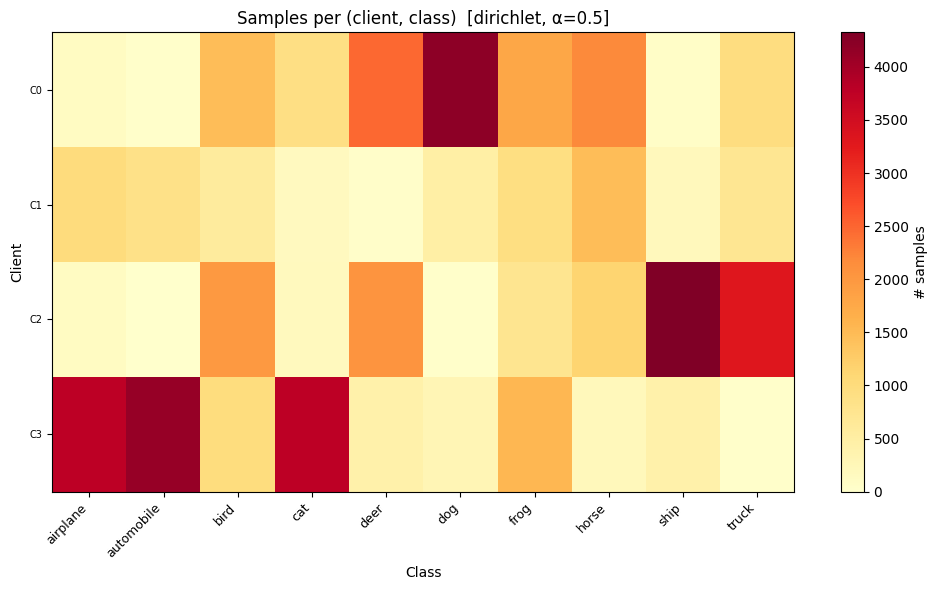

In [6]:
# Pivot to matrix: rows = clients, cols = classes
matrix = df.pivot(index='client_id', columns='class_id', values='num_samples').fillna(0).astype(int)
class_labels = [CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c) for c in matrix.columns]

fig, ax = plt.subplots(figsize=(len(class_labels) * 0.9 + 1, max(6, num_clients * 0.35)))
im = ax.imshow(matrix.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='# samples')

ax.set_xticks(range(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(num_clients))
ax.set_yticklabels([f'C{i}' for i in range(num_clients)], fontsize=7)
ax.set_xlabel('Class')
ax.set_ylabel('Client')
ax.set_title(f'Samples per (client, class)  [{partition}, α={alpha}]')
plt.tight_layout()
plt.show()

## 3 · Stacked bar — class composition per client

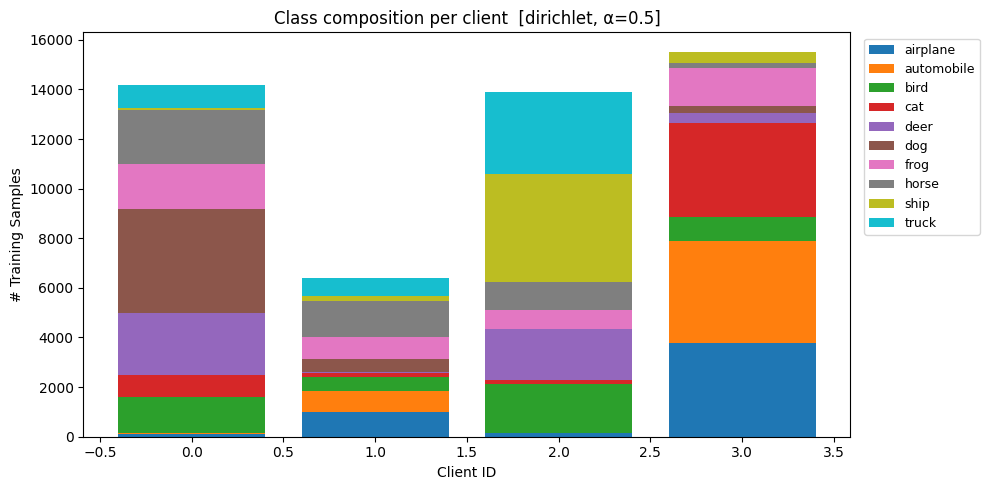

In [7]:
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(matrix.shape[1])]

fig, ax = plt.subplots(figsize=(max(10, num_clients // 2), 5))
bottom = np.zeros(len(matrix))
for j, (col, color) in enumerate(zip(matrix.columns, colors)):
    label = CLASS_NAMES[col] if col < len(CLASS_NAMES) else str(col)
    ax.bar(matrix.index, matrix[col].values, bottom=bottom,
           color=color, label=label, edgecolor='none', width=0.8)
    bottom += matrix[col].values

ax.set_xlabel('Client ID')
ax.set_ylabel('# Training Samples')
ax.set_title(f'Class composition per client  [{partition}, α={alpha}]')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, ncol=1)
plt.tight_layout()
plt.show()

## 4 · Class fraction per client (normalised stacked bar)
Shows the *proportion* of each class, making heterogeneity visible regardless of total sample count.

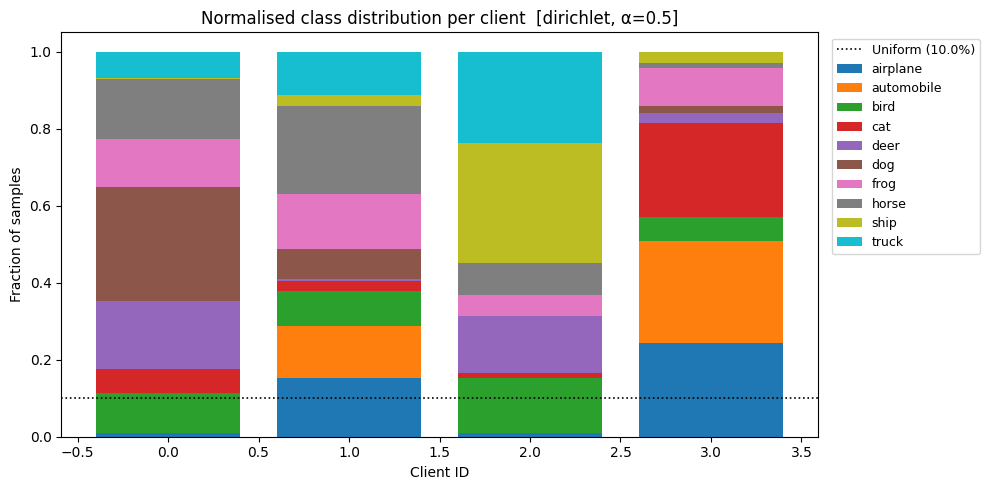

In [8]:
norm_matrix = matrix.div(matrix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(10, num_clients // 2), 5))
bottom = np.zeros(len(norm_matrix))
for j, (col, color) in enumerate(zip(norm_matrix.columns, colors)):
    label = CLASS_NAMES[col] if col < len(CLASS_NAMES) else str(col)
    ax.bar(norm_matrix.index, norm_matrix[col].values, bottom=bottom,
           color=color, label=label, edgecolor='none', width=0.8)
    bottom += norm_matrix[col].values

ax.axhline(1/len(matrix.columns), color='black', linestyle=':', linewidth=1.2,
           label=f'Uniform ({100/len(matrix.columns):.1f}%)')
ax.set_xlabel('Client ID')
ax.set_ylabel('Fraction of samples')
ax.set_title(f'Normalised class distribution per client  [{partition}, α={alpha}]')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 5 · Class-level statistics across clients

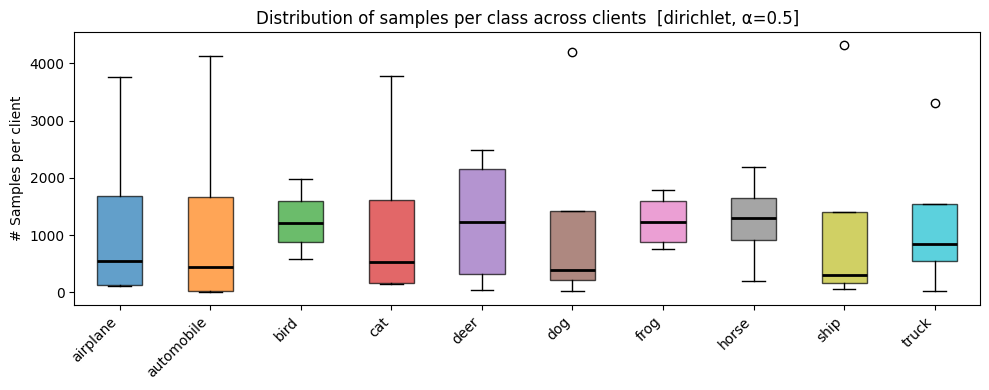

In [9]:
# Box plot: spread of sample counts per class across clients
fig, ax = plt.subplots(figsize=(10, 4))
data_per_class = [matrix[col].values for col in matrix.columns]
bp = ax.boxplot(data_per_class, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(matrix.columns) + 1))
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_ylabel('# Samples per client')
ax.set_title(f'Distribution of samples per class across clients  [{partition}, α={alpha}]')
plt.tight_layout()
plt.show()

## 6 · Summary statistics table

In [10]:
summary = pd.DataFrame({
    'total_samples':   matrix.sum(axis=1),
    'num_classes_present': (matrix > 0).sum(axis=1),
    'dominant_class':  matrix.idxmax(axis=1).map(lambda c: CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c)),
    'dominant_class_pct': (matrix.max(axis=1) / matrix.sum(axis=1) * 100).round(1),
    'min_class_samples': matrix.min(axis=1),
    'max_class_samples': matrix.max(axis=1),
    'std_class_samples': matrix.std(axis=1).round(1),
})
summary.index.name = 'client_id'
print(f'Partition: {partition}  α={alpha}  |  {num_clients} clients  |  {dataset}')
summary

Partition: dirichlet  α=0.5  |  4 clients  |  cifar10


,total_samples,num_classes_present,dominant_class,dominant_class_pct,min_class_samples,max_class_samples,std_class_samples
client_id,,,,,,,
0,14195,10,dog,29.6,24,4206,1316.2
1,6400,10,horse,22.8,44,1457,438.8
2,13880,9,ship,31.2,0,4325,1504.7
3,15525,10,automobile,26.5,20,4120,1670.0
